<a href="https://colab.research.google.com/github/Pranayshukla0610/ML-projects-portfolio/blob/main/Generative_AI_Swapper_Image.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install insightface onnxruntime-gpu opencv-python moviepy -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 762.2/762.2 kB 12.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 277.0/277.0 MB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.6/17.6 MB 33.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.2/18.2 MB 37.2 MB/s eta 0:00:00


In [2]:
import cv2
import insightface
from insightface.app import FaceAnalysis
from insightface.model_zoo import get_model
from google.colab.patches import cv2_imshow
from google.colab import files
import urllib.request

In [3]:
source_url = "https://raw.githubusercontent.com/opencv/opencv/master/samples/data/lena.jpg"

urllib.request.urlretrieve(
    source_url,
    "source.jpg"
)

print("Source image downloaded")

Source image downloaded


In [4]:
uploaded = files.upload()

Saving 740full-lena-(model).jpg to 740full-lena-(model).jpg


In [5]:
app = FaceAnalysis(name='buffalo_l')

app.prepare(
    ctx_id=0,
    det_size=(640, 640)
)

download_path: /root/.insightface/models/buffalo_l


100%|██████████| 281857/281857 [00:06<00:00, 44752.58KB/s]
/usr/local/lib/python3.12/dist-packages/onnxruntime/capi/onnxruntime_inference_collection.py:149: UserWarning: Specified provider 'CUDAExecutionProvider' is not in available provider names.Available providers: 'AzureExecutionProvider, CPUExecutionProvider'
  warnings.warn(


Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /root/.insightface/models/buffalo_l/1k3d68.onnx landmark_3d_68 ['None', 3, 192, 192] 0.0 1.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /root/.insightface/models/buffalo_l/2d106det.onnx landmark_2d_106 ['None', 3, 192, 192] 0.0 1.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /root/.insightface/models/buffalo_l/det_10g.onnx detection [1, 3, '?', '?'] 127.5 128.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /root/.insightface/models/buffalo_l/genderage.onnx genderage ['None', 3, 96, 96] 0.0 1.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /root/.insightface/models/buffalo_l/w600k_r50.onnx recognition ['None', 3, 112, 112] 127.5 127.5
set det-size: (640, 640)


In [7]:
swapper = get_model(
    '/root/.insightface/models/inswapper_128.onnx'
)

Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
inswapper-shape: [1, 3, 128, 128]


In [8]:
source_img = cv2.imread("source.jpg")
target_img = cv2.imread("target.jpg")

In [10]:
import os

print(os.listdir())

['.config', 'source.jpg', '740full-lena-(model).jpg', 'sample_data']


In [14]:
source_img = cv2.imread("source.jpg")

target_img = cv2.imread("740full-lena-(model).jpg")

print(source_img is not None)
print(target_img is not None)

source_faces = app.get(source_img)
target_faces = app.get(target_img)

print("Source Faces:", len(source_faces))
print("Target Faces:", len(target_faces))

True
True
Source Faces: 1
Target Faces: 1


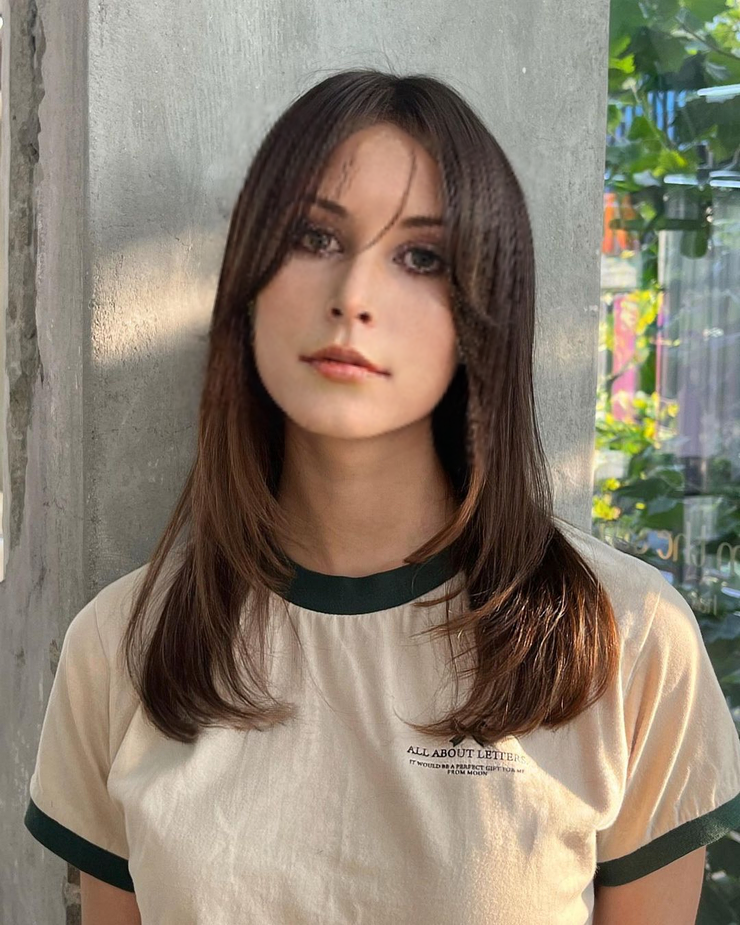

In [15]:
result = swapper.get(
    target_img,
    target_faces[0],
    source_faces[0],
    paste_back=True
)

cv2.imwrite(
    "face_swap_result.jpg",
    result
)

cv2_imshow(result)